# Classifier in Snowpark/Scikit-Learn: Random Forest

This notebook uses Snowpark and the random forest classifer in Python scikit-learn to build a binary classifier, predicting CHURN/NOT CHURN for customers of Snowbear Air.

Steps:
- Setup
- Load and Prepare Customer Churn Data
- Train and Evaluate Model

## Setup

In [10]:
import snowflake.snowpark
from snowflake.snowpark.session import Session
from snowflake.snowpark.functions import *
from snowflake.snowpark.types import *

# config_dir = '/home/jovyan/.ssh'
# configfile = config_dir + '/sf_config'

* Load configuration and connect to Snowflake

In [11]:
# My code for Snowflake account connection

CONFIG_DIR = '/Users/richardkirk/.ssh'
CONFIGFILE = CONFIG_DIR + '/sf_config'


# Load configuration file
with open(CONFIGFILE) as f:
    lines = f.readlines()
    
# Convert configuration to a properties map
props = {}
for line in lines:
    (key, value) = line.split('=')
    props.update({key.lower() : value[0:-1]})
    
# Convert the private key to a DER-encoded bytes object
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.backends import default_backend

with open(props['private_key_file'], "rb") as key:
    private_key = serialization.load_pem_private_key(
        key.read(),
        password=None,
        backend=default_backend()
    )
    
private_key_bytes = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption()
)

# Connect to Snowflake
session = Session.builder.configs({**props, **{"private_key": private_key_bytes}}).create()

## Load and Prepare Customer Churn Data

In [12]:
customer_churnDF = session.table('data_science_db.public.customer_churn')

#### Prepare Data for Modeling

- For training, drop customer ID and surname

In [13]:
customer_churnDF = customer_churnDF.drop('customer_id', 'surname_masked')

- Basic feature engineering: convert categorical features to numeric

In [14]:
customer_churn_tidyDF = (
    customer_churnDF
    .withColumn('GENDER_FEMALE', col('GENDER')=='Female')                          # Convert to numeric
    .withColumn('GEOGRAPHY_FRANCE', col('GEOGRAPHY')=='France')                    # One-
    .withColumn('GEOGRAPHY_SPAIN', col('GEOGRAPHY')=='Spain')                      #   hot-
    .withColumn('GEOGRAPHY_GERMANY', col('GEOGRAPHY')=='Germany')                  #     encoder
    .withColumn('GENDER_FEMALE', col('GENDER_FEMALE').cast(IntegerType()))         # Convert
    .withColumn('GEOGRAPHY_FRANCE', col('GEOGRAPHY_FRANCE').cast(IntegerType()))   #   data
    .withColumn('GEOGRAPHY_SPAIN', col('GEOGRAPHY_SPAIN').cast(IntegerType()))     #     types
    .withColumn('GEOGRAPHY_GERMANY', col('GEOGRAPHY_GERMANY').cast(IntegerType()))
    .drop('gender','geography')
)

In [15]:
customer_churn_tidyDF.show(5)

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"CREDIT_SCORE"  |"AGE"  |"TENURE"  |"MILEAGE_POINTS"  |"NUM_OF_PRODUCTS"  |"HAS_AIRLINE_CREDIT_CARD"  |"IS_ACTIVE_MEMBER"  |"ESTIMATED_SALARY"  |"CHURNED"  |"GENDER_FEMALE"  |"GEOGRAPHY_FRANCE"  |"GEOGRAPHY_SPAIN"  |"GEOGRAPHY_GERMANY"  |
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|555             |35     |4         |0.0               |2                  |0                          |0                   |56552.97            |0          |0                |1                   |0                  |0                    |
|762             |24     |1         |0.0

- Consider correlation between features and target column CHURNED

In [16]:
for colname in customer_churn_tidyDF.columns:
    c = customer_churn_tidyDF.corr(colname, 'churned')
    print(f'{colname:24} {c:4f}')

CREDIT_SCORE             -0.002887
AGE                      0.094279
TENURE                   0.010005
MILEAGE_POINTS           -0.013813
NUM_OF_PRODUCTS          0.089882
HAS_AIRLINE_CREDIT_CARD  0.001201
IS_ACTIVE_MEMBER         -0.124670
ESTIMATED_SALARY         -0.002410
CHURNED                  1.000000
GENDER_FEMALE            0.099187
GEOGRAPHY_FRANCE         -0.058731
GEOGRAPHY_SPAIN          -0.058113
GEOGRAPHY_GERMANY        0.137839


- Create train/test split in Snowpark DataFrames

In [18]:
session.sql("USE DATABASE DATA_SCIENCE_DB").collect() # I had to add this, else get error below that db not set

(trainDF, testDF) = customer_churn_tidyDF.random_split([0.8, 0.2], seed=42)
(trainDF.count(), testDF.count())

(7964, 2036)

## Train and Evaluate Model

* Create Pandas DataFrames to train model

In [19]:
train_x_PDF = trainDF.drop('churned').toPandas()
train_y_PDF = trainDF.select('churned').toPandas()

- Train random forest classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=300)
classifier.fit(train_x_PDF, train_y_PDF.values.ravel())

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


* Plot the feature importances.

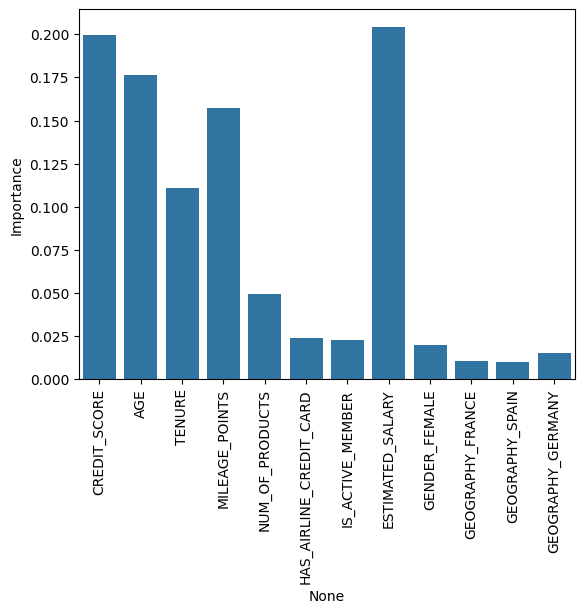

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_feature_importances(importances, featureNames):
    plt.figure()
    imp_plot = sns.barplot(x=featureNames, y=importances)
    plt.setp(imp_plot.get_xticklabels(), rotation=90)
    imp_plot.tick_params(labelsize=10)
    plt.ylabel("Importance")
     
plot_feature_importances(classifier.feature_importances_, train_x_PDF.columns)

*Interpretation:* "Importance" of a feature is a number telling how frequently the feature is used as a decision point in the decision trees that make up the model.

- Generate predictions for test data

In [22]:
# Fetch test data as Pandas DataFrames
test_x_PDF = testDF.drop('churned').toPandas()
test_y_PDF = testDF.select('churned').toPandas()

# Run predictions
predictions = classifier.predict(test_x_PDF)

- Show confusion matrix

In [23]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_y_PDF, predictions)

array([[1402,  102],
       [ 464,   68]])

- Show (accuracy, areaUnderROC)

In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score
acc = accuracy_score(test_y_PDF, predictions)
auc = roc_auc_score(test_y_PDF, predictions)
(acc, auc)

(0.7220039292730844, 0.5300001999680051)

To further improve our predictions for churn, we might consider further experimentation:
- gather more data
- try other models; tune models more extensively
- identify and gather more features with potential predictive value